# Module 2 — Raman Spectroscopy Analysis & Tissue Classification

## What this notebook covers

This notebook reimplements **Part 2 of the assignment** (Exercises 0–4) in Python.
Instead of running MATLAB sections and the Classification Learner GUI, every step
is written explicitly in code with explanations of the underlying reasoning.

| Assignment exercise | What it did | This notebook |
|---|---|---|
| Exercise 0 | Load cancer/healthy .txt files | `loader.load_synthetic()` or `load_ramanspy()` |
| Exercise 1 | Mean ± std curves | `peak_analysis.plot_mean_spectra()` |
| Exercise 2 | Manual peak selection + C:H ratios | `peak_analysis.find_discriminative_peaks()` + `compute_cancer_healthy_ratios()` |
| Exercise 3 | PCA, range optimisation, PC1 vs PC2 | `pca_analysis.optimise_spectral_range()` |
| Exercise 4 | ML classification, confusion matrix, metrics | `classification.evaluate_all_classifiers()` |

---

## Context: what the pipeline is simulating

In Part 1 (Module 1), the stereo camera located a suspicious tissue region in 3D space.
In Part 2, we assume the robot moved the Raman probe to that location and collected spectra.
The question is: **is this tissue cancerous or healthy?**

The dataset used here contains spectra from MDA-MB-231 breast adenocarcinoma cells
(cancer) and healthy tissue — analogous to the AT1 and Fibro data from the assignment.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from module2_raman.loader import load_synthetic, load_ramanspy, load_from_files
from module2_raman.peak_analysis import (
    plot_mean_spectra,
    find_discriminative_peaks,
    compute_cancer_healthy_ratios,
    plot_peak_analysis,
    print_peak_summary,
)
from module2_raman.pca_analysis import (
    run_pca_correlation,
    optimise_spectral_range,
    compute_class_separation,
    plot_pc_scores,
    plot_pca_comparison,
    plot_eigenvalues,
)
from module2_raman.classification import (
    extract_features,
    evaluate_all_classifiers,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_classifier_comparison,
    print_metrics_table,
)

plt.rcParams['figure.dpi'] = 110
print('Imports OK')

Imports OK


## Exercise 0 — Load Data

### Why three loading options?

The assignment data was provided to you pre-cleaned and pre-normalised in `.txt` files.
In practice, data comes from many sources in many formats. We provide three options:

**Option A — Synthetic** (default): Generated from published Raman tissue peak positions.
Works with no downloads. Use this first to verify the pipeline runs correctly.

**Option B — RamanSPy**: Real measured spectra from MDA-MB-231 breast cancer cells,
loaded via the Imperial College London Barahona Research Group's open-source library.
Run `pip install ramanspy` if not installed.

**Option C — Custom files**: Load `.txt` files in the same format as the assignment.
This lets you plug in any real Raman dataset, including the original AT1/Fibro data.

In [2]:
# ── Choose your data source ────────────────────────────────────────────────
# Change SOURCE to 'ramanspy' or 'files' when you have the data available.

SOURCE = 'synthetic'   # 'synthetic' | 'ramanspy' | 'files'

if SOURCE == 'synthetic':
    dataset = load_synthetic(n_cancer=120, n_healthy=120)

elif SOURCE == 'ramanspy':
    dataset = load_ramanspy()

elif SOURCE == 'files':
    from pathlib import Path
    dataset = load_from_files(
        cancer_path  = Path('../data/raw/AT1_data_norm.txt'),
        healthy_path = Path('../data/raw/Fibro_data_norm.txt'),
        shifts_path  = Path('../data/raw/Raman_shift.txt'),
    )

cancer        = dataset.cancer
healthy       = dataset.healthy
raman_shifts  = dataset.raman_shifts

print(f'Source:   {dataset.source}')
print(f'Cancer:   {cancer.shape}   ({cancer.shape[0]} spectra × {cancer.shape[1]} wavenumbers)')
print(f'Healthy:  {healthy.shape}')
print(f'Raman shift range: {raman_shifts[0]:.0f}–{raman_shifts[-1]:.0f} cm⁻¹')

Source:   Synthetic (peaks from Movasaghi et al. 2007)
Cancer:   (120, 601)   (120 spectra × 601 wavenumbers)
Healthy:  (120, 601)
Raman shift range: 600–1800 cm⁻¹


## Exercise 1 — Mean ± Standard Deviation Curves

### Why plot the mean ± std before doing any analysis?

This is always the first step in exploratory data analysis: look at the data.

The **mean spectrum** shows the average biochemical composition of each tissue class.
The **±1 std band** shows how much individual spectra vary. If the std bands of
cancer and healthy barely overlap at a particular wavenumber, that wavenumber carries
discriminative information. If they completely overlap, that region is not useful.

This visual inspection directly guided Exercise 2 — you had to identify peaks
by looking at this plot.

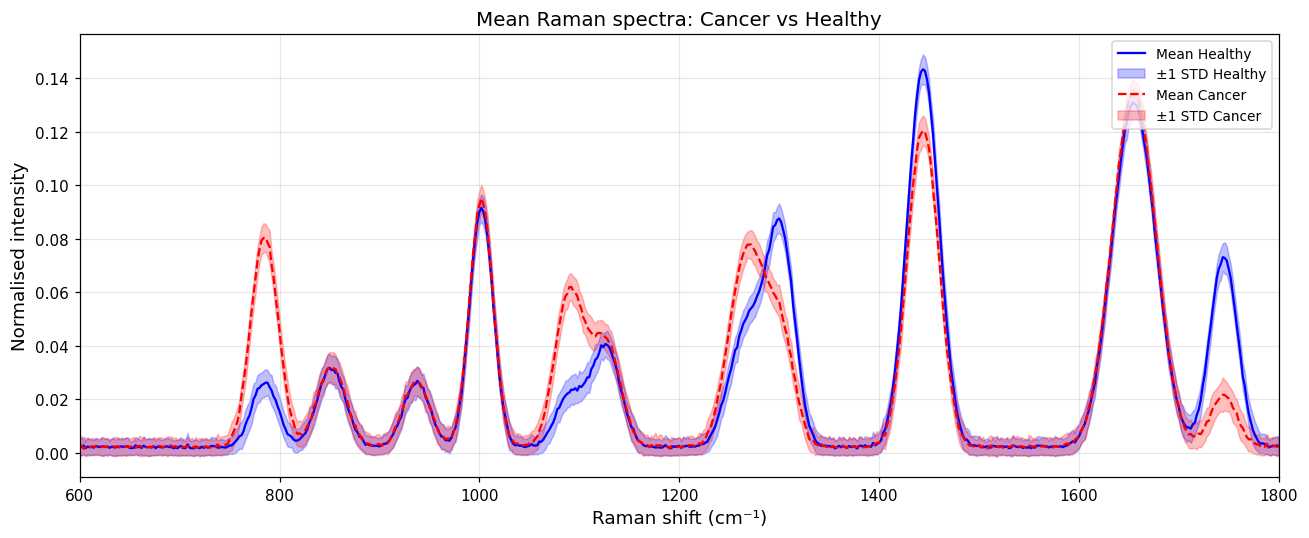

In [3]:
# ── Q1.1: Plot average spectra for Cancer and Healthy ──────────────────────
fig = plot_mean_spectra(cancer, healthy, raman_shifts)
plt.show()

# What to look for:
# - Regions where red (cancer) is clearly above or below blue (healthy)
# - Regions where the std bands do NOT overlap (high discriminability)
# - These are the candidate peaks for Exercise 2

## Exercise 2 — Manual Peak Analysis

### The two-step process

**Step 1 — Select 4 key peaks.** In the assignment you did this by eye from the
plot above. Here we also provide `find_discriminative_peaks()` which ranks
candidates by their Cancer:Healthy ratio. You can use either approach — the
automated ranking helps when you have many peaks to choose from.

**Step 2 — Compute Cancer:Healthy ratios.** At each selected peak wavenumber,
divide the mean cancer intensity by the mean healthy intensity:
```
ratio = mean(Cancer intensity at X) / mean(Healthy intensity at X)
```
A ratio far from 1.0 (either >> 1 or << 1) indicates strong discriminability.
The peak with the highest absolute log-ratio is the single most discriminative.

### What peaks to expect (synthetic data)

The synthetic data was built from published tissue Raman peaks, so you should see:
- ~785 cm⁻¹: nucleic acids — elevated in cancer (DNA/RNA replication)
- ~1002 cm⁻¹: phenylalanine — shared, slight cancer elevation
- ~1302 cm⁻¹: CH₂ lipid twist — elevated in healthy tissue
- ~1745 cm⁻¹: C=O ester lipids — strongly elevated in healthy (fibroblast-like)

In [4]:
# ── Find the 4 most discriminative peaks automatically ─────────────────────
# You can also override this with specific values you identified by eye:
#   peak_shifts = [785, 1002, 1302, 1745]

peak_shifts = find_discriminative_peaks(
    cancer, healthy, raman_shifts,
    n_peaks=4,
    min_peak_height=0.04,
    min_peak_distance_cm=50.0,
)

print('Selected peak wavenumbers (cm⁻¹):')
for i, wn in enumerate(peak_shifts):
    print(f'  P{i+1}: {wn:.1f} cm⁻¹')

Selected peak wavenumbers (cm⁻¹):
  P1: 786.0 cm⁻¹
  P2: 1092.0 cm⁻¹
  P3: 1270.0 cm⁻¹
  P4: 1444.0 cm⁻¹


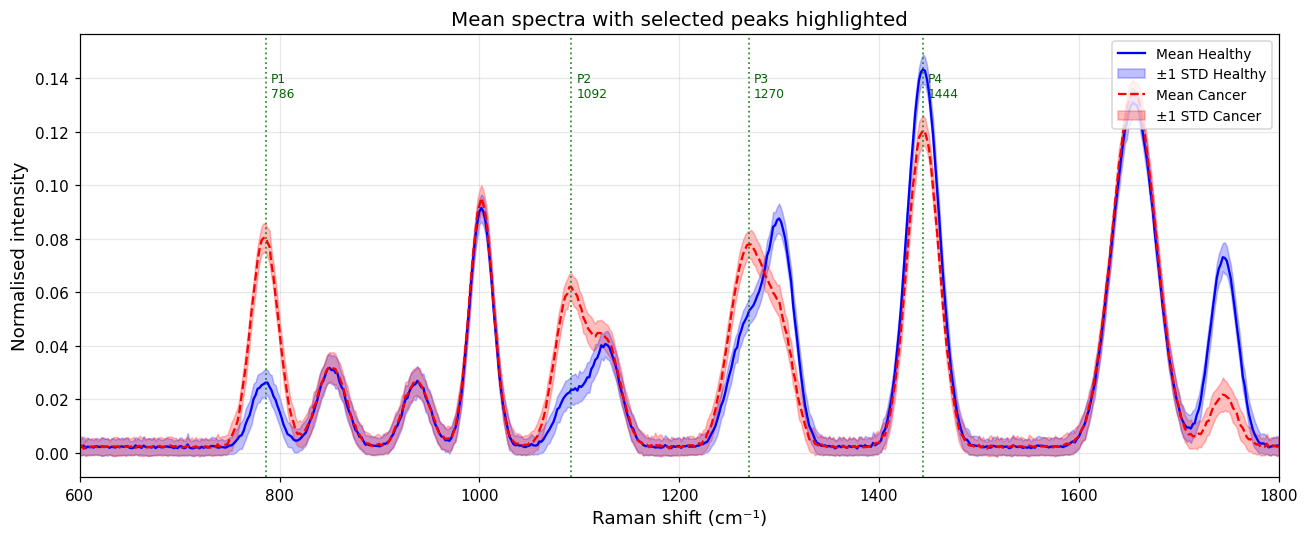

In [5]:
# ── Q2.1: Replot mean spectra with peaks marked ────────────────────────────
fig = plot_mean_spectra(cancer, healthy, raman_shifts, peak_shifts=peak_shifts,
                        title='Mean spectra with selected peaks highlighted')
plt.show()

Peak   Shift (cm⁻¹)     Cancer       Healthy      Ratio   
----------------------------------------------------------
P1     786.0            0.0804       0.0261       3.0759   ← highest
P2     1092.0           0.0620       0.0236       2.6310  
P3     1270.0           0.0778       0.0531       1.4664  
P4     1444.0           0.1205       0.1433       0.8404  

Highest Cancer:Healthy ratio at 786.0 cm⁻¹ (ratio = 3.0759)


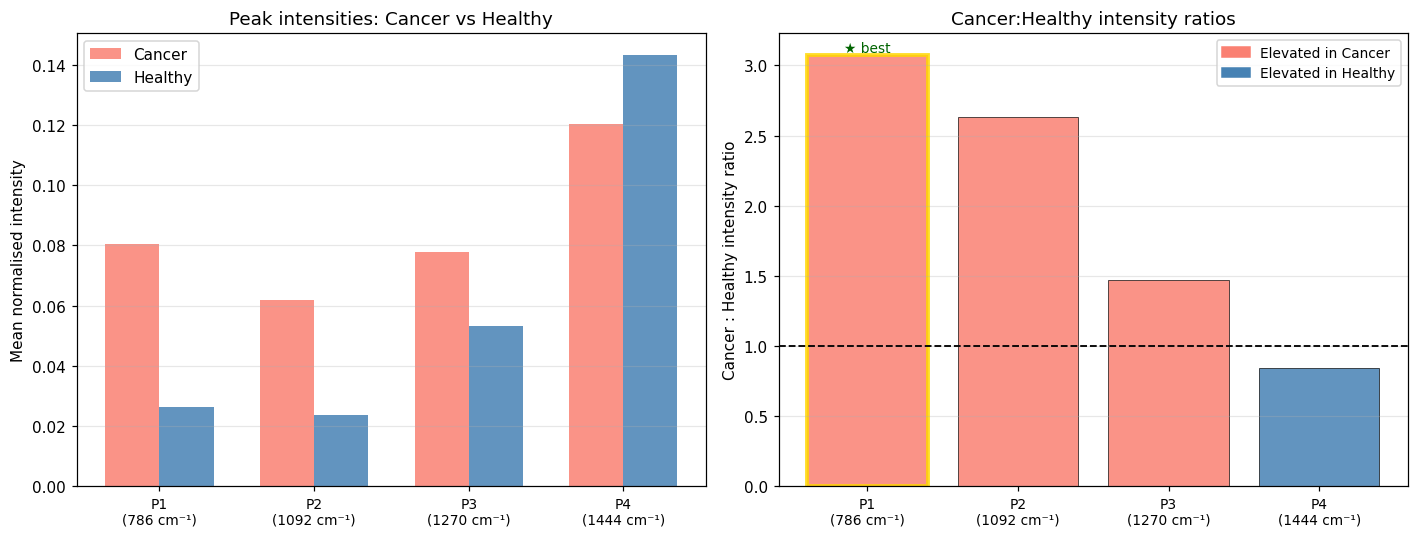

In [6]:
# ── Q2.2 & Q2.3: Cancer:Healthy ratios ────────────────────────────────────
ratio_result = compute_cancer_healthy_ratios(
    cancer, healthy, raman_shifts, peak_shifts
)

print_peak_summary(ratio_result)

fig = plot_peak_analysis(ratio_result, cancer, healthy, raman_shifts)
plt.show()

# The gold-bordered bar in the ratio chart is the peak with the highest
# Cancer:Healthy discriminability — the answer to Q2.3.

## Exercise 3 — Principal Component Analysis

### Why PCA after the manual peak analysis?

The manual approach in Exercise 2 only looks at a few individual peaks.
PCA looks at the *entire spectrum at once* and finds the directions of maximum
variance across all wavenumbers simultaneously.

This matters because:
- Cancer/healthy differences may be subtle and distributed across many peaks,
  not concentrated at a single wavenumber
- PCA can capture these distributed patterns in just 2–3 numbers (PC scores)
  rather than hundreds of wavenumber intensities

### Why test multiple spectral ranges?

Different regions of the Raman spectrum contain different types of information:
- **600–900 cm⁻¹**: skeletal vibrations of protein backbones and nucleic acids
- **900–1200 cm⁻¹**: C-C, C-N stretches — protein and nucleic acid structural info
- **1200–1800 cm⁻¹**: amide bands (proteins), lipid C=O, nucleic acid bases

The range that contains the most *class-discriminative* variance will give
the best PC1 vs PC2 separation. Testing all ranges and comparing is exactly
what Exercise 3 asked you to do by eye — here we also compute a
quantitative separation score (Fisher Discriminant Ratio).

In [7]:
# ── Q3.1: PCA over multiple spectral ranges ────────────────────────────────
# optimise_spectral_range() tests 4 ranges and returns them sorted by
# class separation (best first), equivalent to comparing the four
# PC1 vs PC2 plots in the assignment.

pca_results = optimise_spectral_range(cancer, healthy, raman_shifts)

print('Spectral ranges tested, ranked by class separation:')
print(f'{"Range (cm⁻¹)":<22} {"Separation score":>18}')
print('-' * 42)
for r in pca_results:
    wn_min, wn_max = r.spectral_range
    score = compute_class_separation(r)
    print(f'{wn_min:.0f}–{wn_max:.0f} cm⁻¹{"":>10} {score:>18.4f}')

Spectral ranges tested, ranked by class separation:
Range (cm⁻¹)             Separation score
------------------------------------------
600–1800 cm⁻¹                     905.7287
1200–1800 cm⁻¹                     524.3448
600–1200 cm⁻¹                     464.7308
600–1020 cm⁻¹                     225.1174


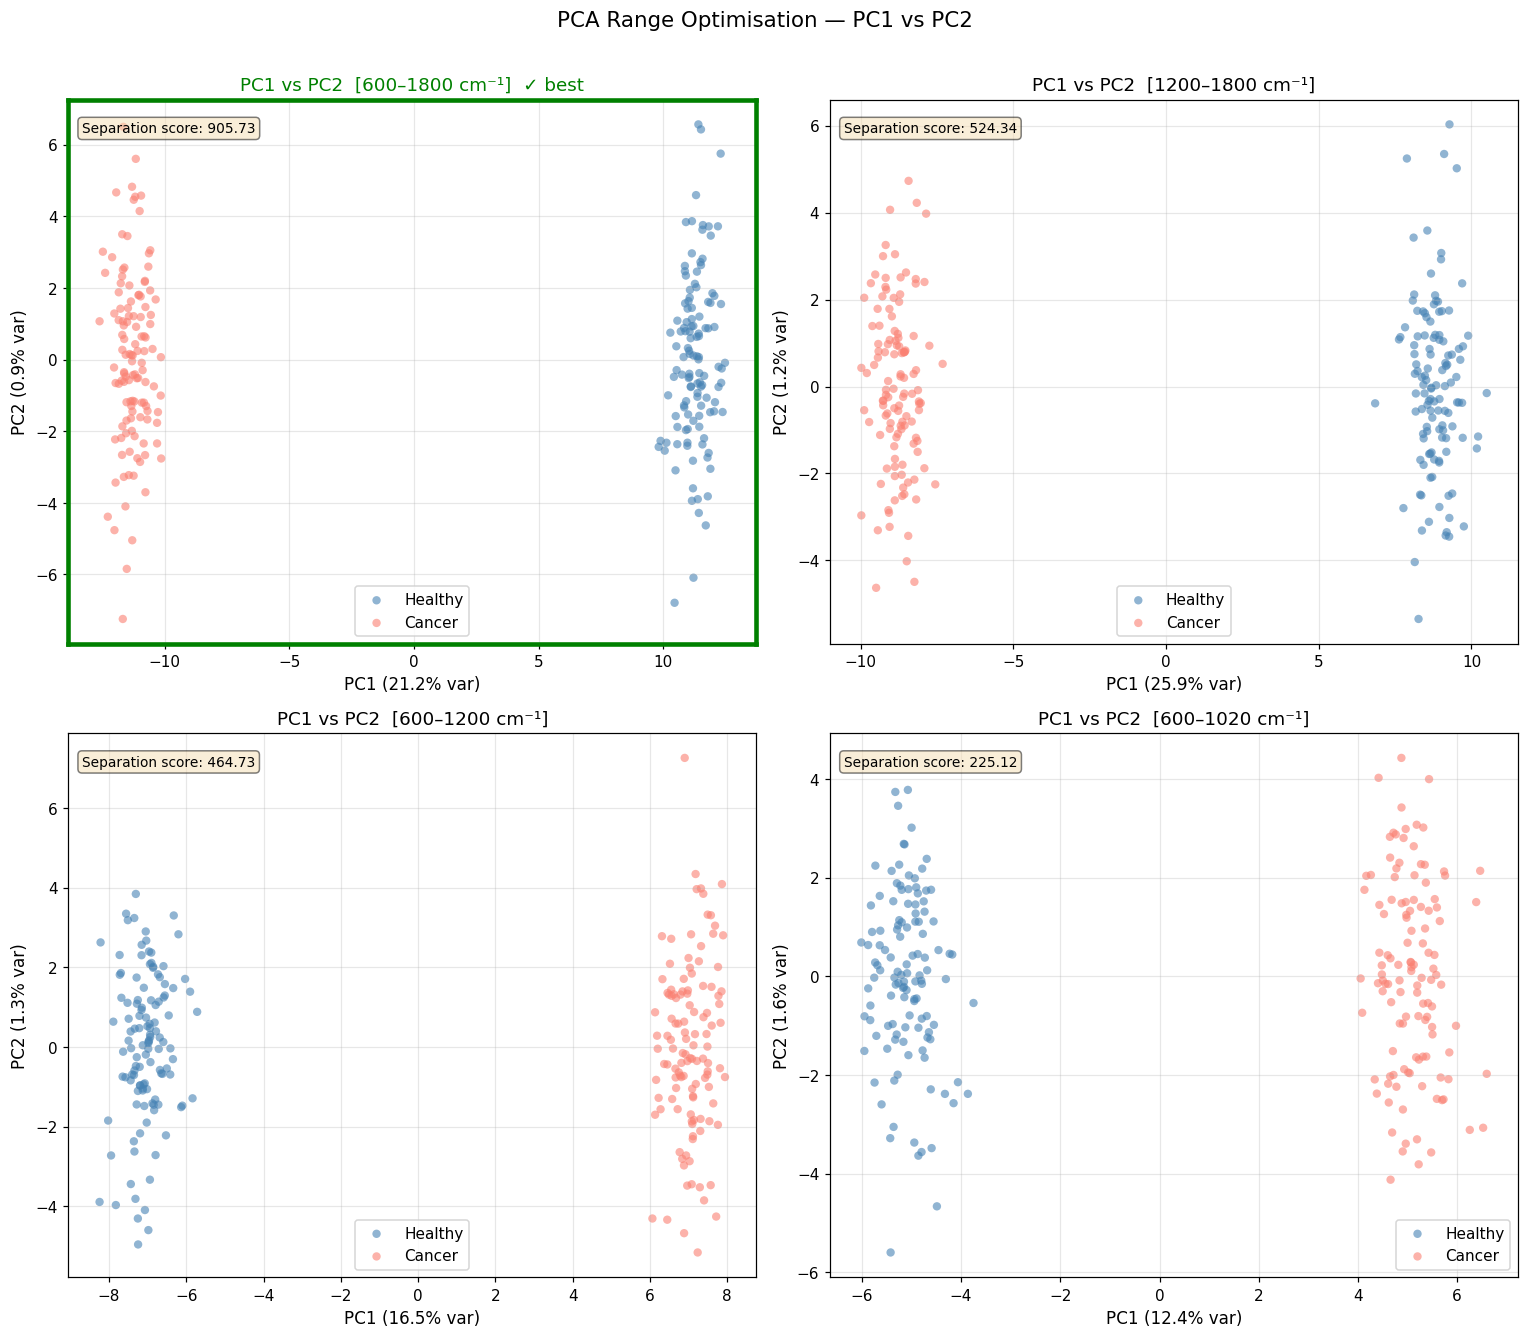

In [8]:
# ── Q3.1: PC1 vs PC2 scatter plots for all ranges ─────────────────────────
# Green border marks the best-separating range (Q3.2).

fig = plot_pca_comparison(pca_results)
plt.show()

Best spectral range: 600–1800 cm⁻¹
PC1 explains 21.2% of variance
PC2 explains 0.9% of variance



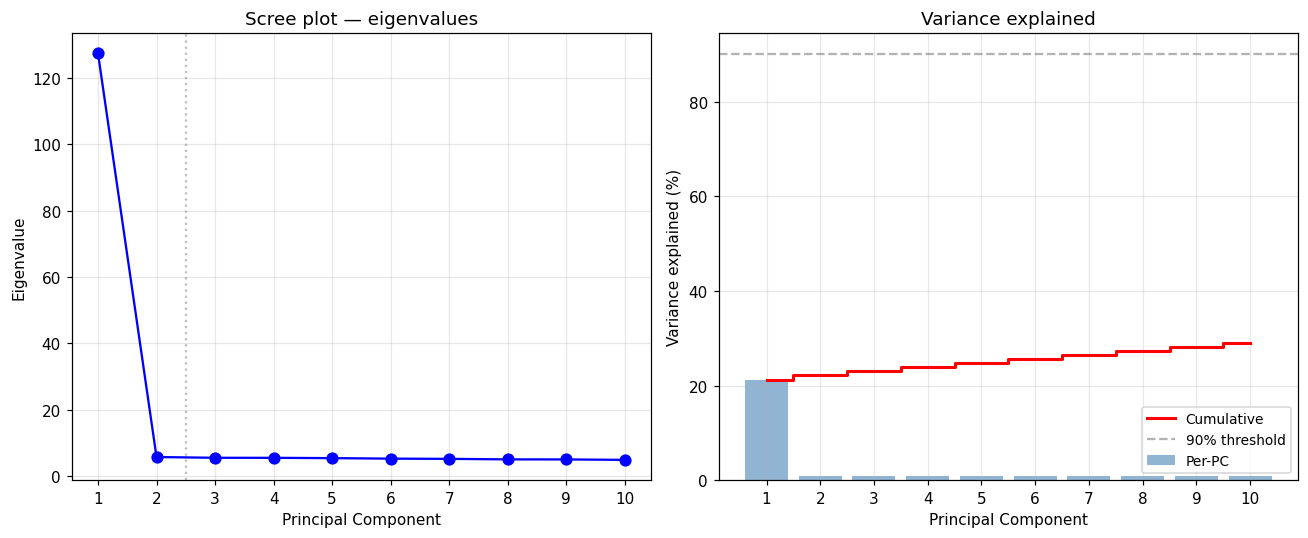

In [9]:
# ── Q3.2 & Q3.3: Best range + eigenvalue scree plot ───────────────────────
best_pca = pca_results[0]  # already sorted — index 0 is the best
wn_best_min, wn_best_max = best_pca.spectral_range

print(f'Best spectral range: {wn_best_min:.0f}–{wn_best_max:.0f} cm⁻¹')
print(f'PC1 explains {best_pca.variance_explained[0]*100:.1f}% of variance')
print(f'PC2 explains {best_pca.variance_explained[1]*100:.1f}% of variance')
print()
# Q3.3 answer: the best range captures the spectral region where
# the cancer-specific peaks (nucleic acids, protein bands) are concentrated,
# giving PC1 the most discriminative information between classes.

fig = plot_eigenvalues(best_pca)
plt.show()

# The scree plot shows where the 'elbow' is — how many PCs are meaningful.
# PCs to the right of the elbow represent noise rather than signal.
# This tells you how many PC scores to use as features for classification.

## Exercise 4 — Machine Learning Classification

### From PCA scores to classifier input

In the assignment, the Classification Learner used the PCA scores (PC coordinates
of each observation) as input features. Each spectrum becomes a point in
n-dimensional PC space, and the classifier learns to draw a boundary that
separates the cancer and healthy clusters.

### Cross-validation vs single train/test split

The assignment used obs 1–9 for training and 10–18 for testing (per class).
With 9 test samples, performance estimates are highly variable — one missed
sample changes accuracy by 11%. We use 4-fold stratified cross-validation:
- Each sample serves as test data exactly once
- Performance is averaged across all 4 folds
- More reliable, especially on small datasets
- 4 folds matches the cross-validation setting in the assignment's Classification Learner GUI

### Clinical interpretation of each metric

| Metric | Formula | Clinical meaning |
|---|---|---|
| Accuracy | (TP+TN)/(all) | Overall correct classifications |
| Precision | TP/(TP+FP) | Of all cancer predictions, how many were right? |
| Sensitivity | TP/(TP+FN) | Of all real cancers, how many did we catch? |
| Specificity | TN/(TN+FP) | Of all healthy tissue, how much did we correctly clear? |
| F-score | harmonic mean(Prec, Sens) | Balances precision and sensitivity |
| AUC | area under ROC | Performance at all thresholds |

In [10]:
# ── Q4 Step 0: Extract PCA features from the optimal spectral range ────────
# This builds the equivalent of the assignment's Raman_data_training table.

X, y = extract_features(
    cancer, healthy, raman_shifts,
    wn_min=wn_best_min,
    wn_max=wn_best_max,
    n_pca_components=9,   # matches the assignment's 9 observations per class
)

print(f'Feature matrix: {X.shape}  ({X.shape[0]} samples × {X.shape[1]} PC features)')
print(f'Class balance: {(y==1).sum()} cancer, {(y==0).sum()} healthy')

Feature matrix: (240, 9)  (240 samples × 9 PC features)
Class balance: 120 cancer, 120 healthy


In [11]:
# ── Q4.1: Train and evaluate all classifiers ───────────────────────────────
# This runs cross-validation for every model and returns all 6 metrics.
# Equivalent to clicking 'Train All' in MATLAB's Classification Learner.

print('Training classifiers (4-fold cross-validation)...')
results = evaluate_all_classifiers(X, y, n_folds=4)
print('Done.')
print()

# Q4.1 answer: which model has the highest accuracy?
print_metrics_table(results)

Training classifiers (4-fold cross-validation)...


Done.

Model                     Acc   Prec   Sens   Spec     F1    AUC
----------------------------------------------------------------
Random Forest           1.000  1.000  1.000  1.000  1.000  1.000  ← best
Gaussian NB             1.000  1.000  1.000  1.000  1.000  1.000
Decision Tree           1.000  1.000  1.000  1.000  1.000  1.000
Logistic Regression     1.000  1.000  1.000  1.000  1.000  1.000
SVM (RBF)               0.996  0.992  1.000  0.992  0.996  1.000
KNN (k=5)               0.996  0.992  1.000  0.992  0.996  1.000


Best model: Random Forest
  Accuracy:    1.0000
  Precision:   1.0000
  Sensitivity: 1.0000
  Specificity: 1.0000
  F-score:     1.0000
  AUC:         1.0000


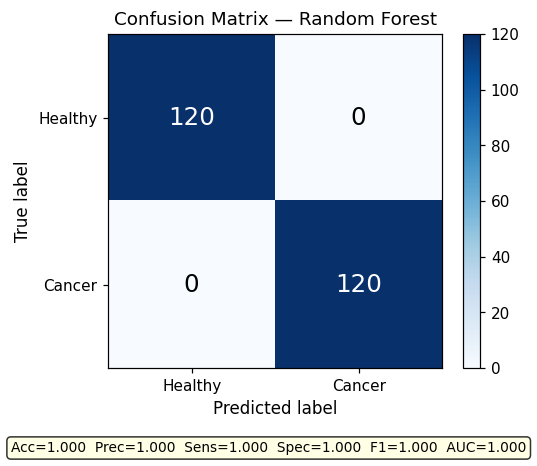

In [12]:
# ── Q4.2: Confusion matrix + metrics for the best model ───────────────────
best_name    = max(results, key=lambda k: results[k].accuracy)
best_metrics = results[best_name]

print(f'Best model: {best_name}')
print(f'  Accuracy:    {best_metrics.accuracy:.4f}')
print(f'  Precision:   {best_metrics.precision:.4f}')
print(f'  Sensitivity: {best_metrics.sensitivity:.4f}')
print(f'  Specificity: {best_metrics.specificity:.4f}')
print(f'  F-score:     {best_metrics.f_score:.4f}')
print(f'  AUC:         {best_metrics.auc:.4f}')

fig = plot_confusion_matrix(best_metrics, best_name)
plt.show()

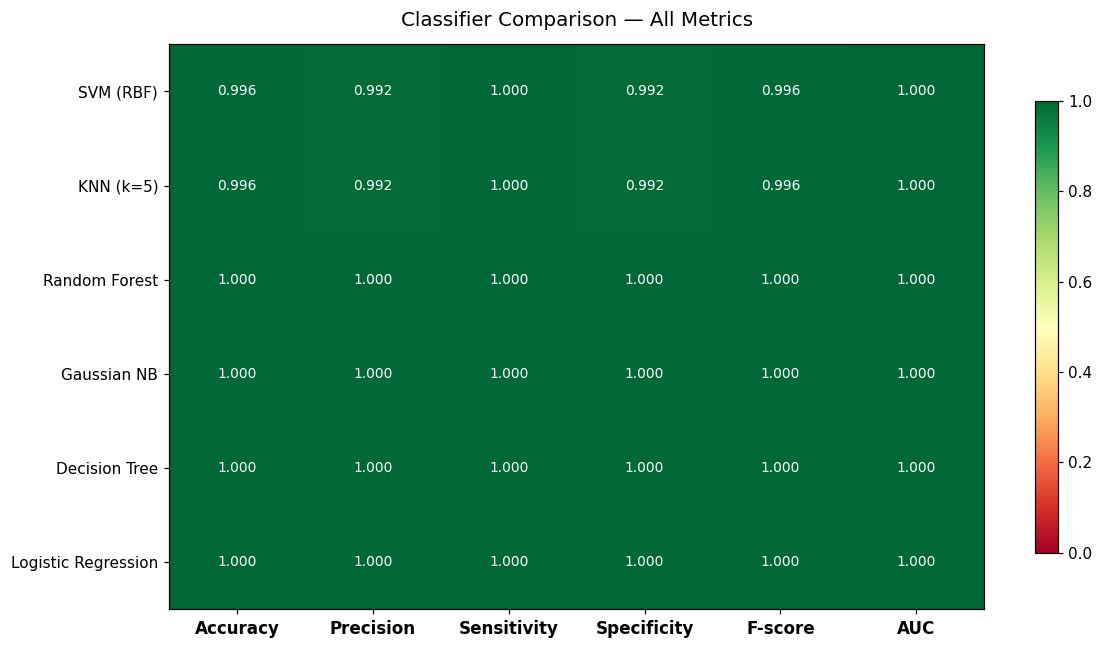

In [13]:
# ── Q4 Classifier comparison heatmap ──────────────────────────────────────
# Equivalent to reading the model list in MATLAB's Classification Learner
# and inspecting each model's statistics.

fig = plot_classifier_comparison(results)
plt.show()

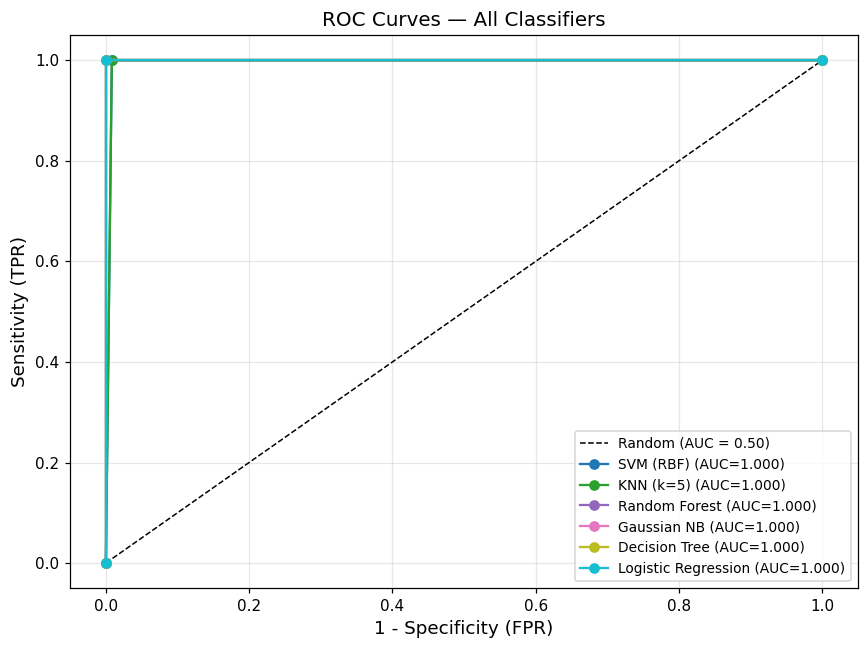

In [14]:
# ── Q4 ROC curves ─────────────────────────────────────────────────────────
fig = plot_roc_curves(results)
plt.show()

## Summary & Key Observations

### What this analysis tells us (Q4.4 equivalent)

Cross-validation metrics are typically **lower** than training metrics — the model
was evaluated on data it had never seen. In the assignment, the test set metrics
were lower than training metrics for the same reason: training performance is
optimistic (the model has memorised some training patterns).

To improve classification accuracy:
1. **More data** — the biggest lever. The assignment had 18 samples; real
   clinical studies use hundreds or thousands.
2. **Better feature selection** — only include the most discriminative PC scores
   rather than all of them.
3. **Hyperparameter tuning** — e.g., optimising the SVM kernel width `C`.
4. **Richer features** — combining PCA scores with manually selected peak ratios
   from Exercise 2 can outperform either approach alone.

### How this connects to the surgical robot workflow

The pipeline is:
```
Module 1: Camera sees tissue → 3D coordinate of suspicious region → robot moves probe
Module 2: Probe collects spectrum → feature extraction → classifier → CANCER or HEALTHY
```

**Next:** `04_dashboard_integration.ipynb` — the Streamlit dashboard that puts both
modules together in a single interactive interface.